# United Kingdom Top 50 Playlist Market Structure, Artist Diversity & Content Localization Analysis

### Atlantic Recording Corporation | Unified Mentor Internship

---

## Project Objective

This project analyzes the United Kingdom Top 50 playlist to understand:

- Artist dominance and market concentration
- Artist diversity across daily playlists
- Collaboration patterns
- Explicit vs clean content performance
- Single vs album release strategy
- Track duration characteristics

The objective is to generate UK-specific market intelligence that can support artist signing, marketing strategies, and release planning.

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Streamlit
- VS Code

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

file_path = Path("../Data/Atlantic_United_Kingdom.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 27,800
Columns: 10


In [3]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Tattoo,Loreen,89,183374,single,1,False,https://i.scdn.co/image/ab67616d0000b2732b0ba8...
1,18-05-2024,2,Daylight,David Kushner,96,212953,single,1,False,https://i.scdn.co/image/ab67616d0000b27395ca6a...
2,18-05-2024,3,Cha Cha Cha,Käärijä,86,175161,single,1,False,https://i.scdn.co/image/ab67616d0000b273e9973a...
3,18-05-2024,4,Miracle (with Ellie Goulding),Calvin Harris & Ellie Goulding,91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...
4,18-05-2024,5,Queen of Kings,Alessandra,85,147979,single,1,False,https://i.scdn.co/image/ab67616d0000b2732c9eea...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   date             27800 non-null  str  
 1   position         27800 non-null  int64
 2   song             27800 non-null  str  
 3   artist           27800 non-null  str  
 4   popularity       27800 non-null  int64
 5   duration_ms      27800 non-null  int64
 6   album_type       27800 non-null  str  
 7   total_tracks     27800 non-null  int64
 8   is_explicit      27800 non-null  bool 
 9   album_cover_url  27800 non-null  str  
dtypes: bool(1), int64(4), str(5)
memory usage: 1.9 MB


#  Data Quality Assessment

Before performing exploratory analysis, the dataset is validated for:

- Missing values
- Duplicate records
- Duplicate date-position combinations
- Daily Top 50 completeness
- Position range
- Data types
- Categorical values
- Date consistency

The original dataset is preserved without modification. Any cleaning will
be performed on a separate analysis dataframe.

In [5]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by column:
date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64

Total missing values: 0


In [6]:
# ============================================================
# DUPLICATE RECORD CHECK
# ============================================================

duplicate_rows = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

Exact duplicate rows: 12


In [7]:
# ============================================================
# DUPLICATE DATE-POSITION CHECK
# ============================================================

duplicate_date_position = df.duplicated(
    subset=["date", "position"],
    keep=False
).sum()

print("Rows involved in duplicate date-position combinations:",
      duplicate_date_position)

Rows involved in duplicate date-position combinations: 100


In [8]:
# ============================================================
# DAILY PLAYLIST SIZE VALIDATION
# ============================================================

daily_counts = df.groupby("date").size()

print("Number of unique dates:", daily_counts.nunique())
print("Total unique dates:", daily_counts.shape[0])

print("\nDaily record count distribution:")
print(daily_counts.value_counts().sort_index())

Number of unique dates: 2
Total unique dates: 555

Daily record count distribution:
50     554
100      1
Name: count, dtype: int64


In [9]:
# Dates that do not contain exactly 50 records

invalid_dates = daily_counts[daily_counts != 50]

print("Dates with record count different from 50:")
print(invalid_dates)

Dates with record count different from 50:
date
01-03-2025    100
dtype: int64


In [10]:
# ============================================================
# POSITION VALIDATION
# ============================================================

print("Minimum position:", df["position"].min())
print("Maximum position:", df["position"].max())

invalid_positions = df[
    (df["position"] < 1) |
    (df["position"] > 50)
]

print("Invalid position records:", len(invalid_positions))

Minimum position: 1
Maximum position: 50
Invalid position records: 0


In [11]:
# ============================================================
# ALBUM TYPE VALIDATION
# ============================================================

print("Album types:")
print(df["album_type"].value_counts())

Album types:
album_type
album          16669
single         11053
compilation       78
Name: count, dtype: int64


In [12]:
# ============================================================
# EXPLICIT CONTENT VALIDATION
# ============================================================

print("Explicit content values:")
print(df["is_explicit"].value_counts())

Explicit content values:
is_explicit
False    18888
True      8912
Name: count, dtype: int64


In [13]:
# ============================================================
# CREATE ANALYSIS DATAFRAME
# ============================================================

analysis_df = df.copy()

analysis_df["date"] = pd.to_datetime(
    analysis_df["date"],
    format="%d-%m-%Y"
)

print("Date conversion completed.")
print(analysis_df["date"].dtype)

Date conversion completed.
datetime64[us]


In [14]:
# ============================================================
# INVESTIGATE INVALID DATE
# ============================================================

problem_date = "01-03-2025"

problem_data = analysis_df[
    analysis_df["date"] == pd.Timestamp("2025-03-01")
].sort_values("position")

print("Records for", problem_date, ":", len(problem_data))

problem_data[["position", "song", "artist"]].head(20)

Records for 01-03-2025 : 100


,position,song,artist
14350,1,TEXAS HOLD 'EM,Beyoncé
14400,1,Stick Season,Noah Kahan
14401,2,TEXAS HOLD 'EM,Beyoncé
14351,2,Stick Season,Noah Kahan
14352,3,Beautiful Things,Benson Boone
14402,3,Beautiful Things,Benson Boone
14403,4,End of Beginning,Djo
14353,4,End of Beginning,Djo
14354,5,Lose Control,Teddy Swims
14404,5,Lose Control,Teddy Swims


In [15]:
problem_data[["position", "song", "artist"]].tail(20)

,position,song,artist
14440,41,Sprinter,Dave & Central Cee
14390,41,leavemealone,Fred again..
14391,42,Kitchen Stove,Pozer
14441,42,"One Of The Girls (with JENNIE, Lily Rose Depp)",The Weeknd
14442,43,Kitchen Stove,Pozer
14392,43,Mr. Brightside,The Killers
14393,44,"One Of The Girls (with JENNIE, Lily Rose Depp)",The Weeknd
14443,44,Evergreen,Richy Mitch & The Coal Miners
14444,45,One Dance,Drake
14394,45,What Was I Made For? [From The Motion Picture ...,Billie Eilish


In [16]:
# ============================================================
# CLEAN DAILY TOP 50 DATA
# ============================================================

clean_df = (
    analysis_df
    .drop_duplicates(
        subset=["date", "position"],
        keep="first"
    )
    .copy()
)

print("Original records:", len(analysis_df))
print("Cleaned records:", len(clean_df))

Original records: 27800
Cleaned records: 27750


In [17]:
# ============================================================
# VERIFY CLEAN DATASET
# ============================================================

clean_daily_counts = clean_df.groupby("date").size()

print("Minimum records per day:", clean_daily_counts.min())
print("Maximum records per day:", clean_daily_counts.max())

print(
    "All dates contain exactly 50 records:",
    (clean_daily_counts == 50).all()
)

Minimum records per day: 50
Maximum records per day: 50
All dates contain exactly 50 records: True


#  Feature Engineering

Additional analytical features are created from the cleaned dataset to support
artist diversity, collaboration, content, release-format, ranking, and
track-duration analysis.

In [18]:
# ============================================================
# TRACK DURATION
# ============================================================

clean_df["duration_minutes"] = clean_df["duration_ms"] / 60000

clean_df[["duration_ms", "duration_minutes"]].head()

,duration_ms,duration_minutes
0,183374,3.056233
1,212953,3.549217
2,175161,2.919350
3,186496,3.108267
4,147979,2.466317


In [19]:
# ============================================================
# RANK GROUP
# ============================================================

def rank_group(position):
    if position <= 10:
        return "Top 10"
    elif position <= 25:
        return "11-25"
    else:
        return "26-50"

clean_df["rank_group"] = clean_df["position"].apply(rank_group)

clean_df["rank_group"].value_counts()

rank_group
26-50     13875
11-25      8325
Top 10     5550
Name: count, dtype: int64

In [20]:
# ============================================================
# COLLABORATION IDENTIFICATION
# ============================================================

clean_df["is_collaboration"] = clean_df["artist"].str.contains(
    "&",
    regex=False,
    na=False
)

clean_df["is_collaboration"].value_counts()

is_collaboration
False    22633
True      5117
Name: count, dtype: int64

In [21]:
# ============================================================
# NUMBER OF ARTISTS PER TRACK
# ============================================================

clean_df["artist_count"] = (
    clean_df["artist"]
    .str.split("&")
    .str.len()
)

clean_df[["artist", "artist_count"]].head(10)

,artist,artist_count
0,Loreen,1
1,David Kushner,1
2,Käärijä,1
3,Calvin Harris & Ellie Goulding,2
4,Alessandra,1
5,Miley Cyrus,1
6,PinkPantheress & Ice Spice,2
7,Libianca,1
8,SZA,1
9,Lewis Capaldi,1


In [22]:
# ============================================================
# POPULARITY BUCKET
# ============================================================

def popularity_bucket(score):
    if score >= 90:
        return "90-100"
    elif score >= 80:
        return "80-89"
    elif score >= 70:
        return "70-79"
    elif score >= 60:
        return "60-69"
    else:
        return "Below 60"

clean_df["popularity_bucket"] = clean_df["popularity"].apply(
    popularity_bucket
)

clean_df["popularity_bucket"].value_counts()

popularity_bucket
90-100      12282
80-89       11670
70-79        2773
Below 60      514
60-69         511
Name: count, dtype: int64

In [23]:
# ============================================================
# DATE FEATURES
# ============================================================

clean_df["year"] = clean_df["date"].dt.year
clean_df["month"] = clean_df["date"].dt.month
clean_df["month_name"] = clean_df["date"].dt.month_name()

print("Date features created successfully.")

Date features created successfully.


In [24]:
# ============================================================
# FEATURE ENGINEERING CHECK
# ============================================================

clean_df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_minutes,rank_group,is_collaboration,artist_count,popularity_bucket,year,month,month_name
0,2024-05-18,1,Tattoo,Loreen,89,183374,single,1,False,https://i.scdn.co/image/ab67616d0000b2732b0ba8...,3.056233,Top 10,False,1,80-89,2024,5,May
1,2024-05-18,2,Daylight,David Kushner,96,212953,single,1,False,https://i.scdn.co/image/ab67616d0000b27395ca6a...,3.549217,Top 10,False,1,90-100,2024,5,May
2,2024-05-18,3,Cha Cha Cha,Käärijä,86,175161,single,1,False,https://i.scdn.co/image/ab67616d0000b273e9973a...,2.919350,Top 10,False,1,80-89,2024,5,May
3,2024-05-18,4,Miracle (with Ellie Goulding),Calvin Harris & Ellie Goulding,91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...,3.108267,Top 10,True,2,90-100,2024,5,May
4,2024-05-18,5,Queen of Kings,Alessandra,85,147979,single,1,False,https://i.scdn.co/image/ab67616d0000b2732c9eea...,2.466317,Top 10,False,1,80-89,2024,5,May


In [25]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 27750 entries, 0 to 27799
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               27750 non-null  datetime64[us]
 1   position           27750 non-null  int64         
 2   song               27750 non-null  str           
 3   artist             27750 non-null  str           
 4   popularity         27750 non-null  int64         
 5   duration_ms        27750 non-null  int64         
 6   album_type         27750 non-null  str           
 7   total_tracks       27750 non-null  int64         
 8   is_explicit        27750 non-null  bool          
 9   album_cover_url    27750 non-null  str           
 10  duration_minutes   27750 non-null  float64       
 11  rank_group         27750 non-null  str           
 12  is_collaboration   27750 non-null  bool          
 13  artist_count       27750 non-null  int64         
 14  popularity_bucket  277

In [26]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 27750 entries, 0 to 27799
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               27750 non-null  datetime64[us]
 1   position           27750 non-null  int64         
 2   song               27750 non-null  str           
 3   artist             27750 non-null  str           
 4   popularity         27750 non-null  int64         
 5   duration_ms        27750 non-null  int64         
 6   album_type         27750 non-null  str           
 7   total_tracks       27750 non-null  int64         
 8   is_explicit        27750 non-null  bool          
 9   album_cover_url    27750 non-null  str           
 10  duration_minutes   27750 non-null  float64       
 11  rank_group         27750 non-null  str           
 12  is_collaboration   27750 non-null  bool          
 13  artist_count       27750 non-null  int64         
 14  popularity_bucket  277

In [27]:
# ============================================================
# SAVE CLEANED DATASET
# ============================================================

cleaned_file_path = Path("../Data/Atlantic_United_Kingdom_Cleaned.csv")

clean_df.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset saved successfully.")
print(cleaned_file_path)

Cleaned dataset saved successfully.
..\Data\Atlantic_United_Kingdom_Cleaned.csv


#  Artist Dominance & Diversity Analysis

This section evaluates the distribution of artists across the UK Top 50
playlist.

The analysis focuses on:

- Unique artist count
- Total appearances by artist
- Top-dominating artists
- Artist concentration
- Market diversity

In [28]:
# ============================================================
# UNIQUE ARTIST COUNT
# ============================================================

unique_artists = clean_df["artist"].nunique()

print("Total unique artist entries:", unique_artists)

Total unique artist entries: 343


In [29]:
# ============================================================
# ARTIST APPEARANCES
# ============================================================

artist_appearances = (
    clean_df["artist"]
    .value_counts()
    .reset_index()
)

artist_appearances.columns = ["artist", "appearances"]

artist_appearances.head(10)

,artist,appearances
0,Taylor Swift,2091
1,Sabrina Carpenter,964
2,Billie Eilish,818
3,Olivia Rodrigo,642
4,Chappell Roan,634
5,Benson Boone,537
6,The Killers,511
7,Dua Lipa,484
8,Drake,452
9,Teddy Swims,433


In [30]:
# ============================================================
# TOP 10 DOMINATING ARTISTS
# ============================================================

top_10_artists = artist_appearances.head(10)

print("Top 10 artist entries by playlist appearances:")
print(top_10_artists)

Top 10 artist entries by playlist appearances:
              artist  appearances
0       Taylor Swift         2091
1  Sabrina Carpenter          964
2      Billie Eilish          818
3     Olivia Rodrigo          642
4      Chappell Roan          634
5       Benson Boone          537
6        The Killers          511
7           Dua Lipa          484
8              Drake          452
9        Teddy Swims          433


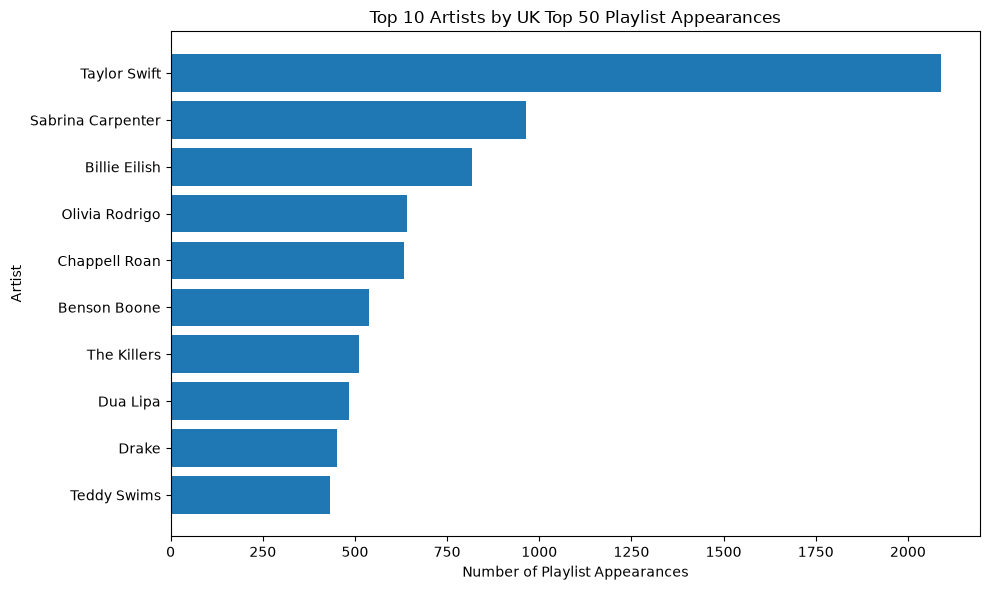

In [31]:
# ============================================================
# TOP 10 ARTIST DOMINANCE
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_artists["artist"][::-1],
    top_10_artists["appearances"][::-1]
)

plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Artist")
plt.title("Top 10 Artists by UK Top 50 Playlist Appearances")

plt.tight_layout()

plt.show()

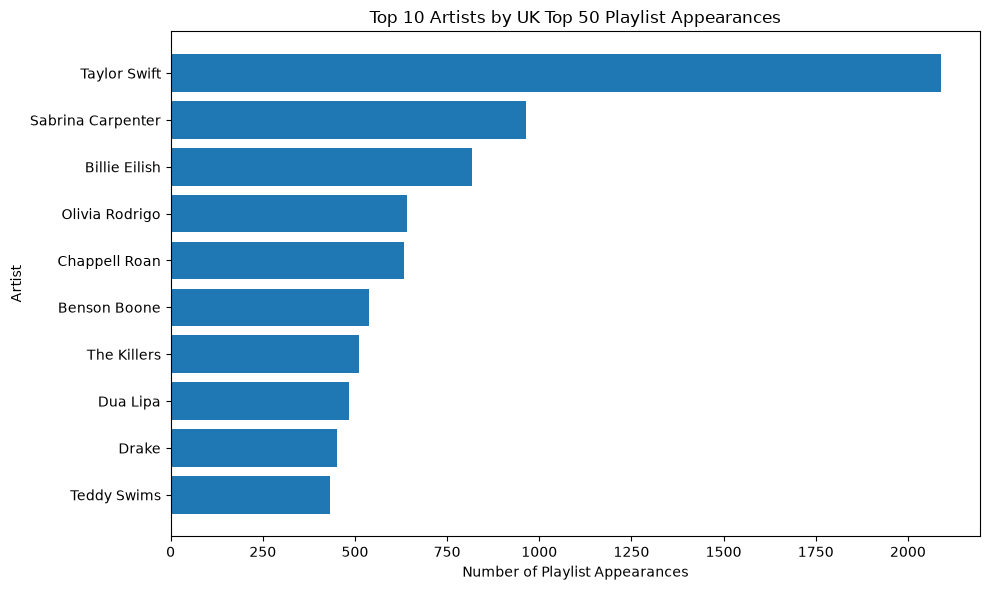

In [32]:
# ============================================================
# SAVE VISUALIZATION
# ============================================================

chart_path = "../Visualizations/top_10_artist_dominance.png"

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_artists["artist"][::-1],
    top_10_artists["appearances"][::-1]
)

plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Artist")
plt.title("Top 10 Artists by UK Top 50 Playlist Appearances")

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

##  Individual Artist Decomposition

Collaborative tracks may contain multiple artists separated by `&`.
To measure artist diversity and concentration more accurately, collaborative
artist entries are decomposed into individual artists.

In [33]:
# ============================================================
# SPLIT COLLABORATIVE ARTISTS
# ============================================================

artist_expanded = clean_df.copy()

artist_expanded["artist"] = artist_expanded["artist"].str.split("&")

artist_expanded = artist_expanded.explode("artist")

artist_expanded["artist"] = artist_expanded["artist"].str.strip()

print("Original playlist records:", len(clean_df))
print("Expanded artist records:", len(artist_expanded))

Original playlist records: 27750
Expanded artist records: 35086


In [34]:
# ============================================================
# CHECK INDIVIDUAL ARTISTS
# ============================================================

print("True unique individual artists:",
      artist_expanded["artist"].nunique())

artist_expanded[["song", "artist"]].head(15)

True unique individual artists: 363


,song,artist
0,Tattoo,Loreen
1,Daylight,David Kushner
2,Cha Cha Cha,Käärijä
3,Miracle (with Ellie Goulding),Calvin Harris
3,Miracle (with Ellie Goulding),Ellie Goulding
4,Queen of Kings,Alessandra
5,Flowers,Miley Cyrus
6,Boy's a Liar Pt. 2,PinkPantheress
6,Boy's a Liar Pt. 2,Ice Spice
7,People,Libianca


In [35]:
# ============================================================
# TOP INDIVIDUAL ARTISTS
# ============================================================

individual_artist_appearances = (
    artist_expanded["artist"]
    .value_counts()
    .reset_index()
)

individual_artist_appearances.columns = [
    "artist",
    "appearances"
]

individual_artist_appearances.head(10)

,artist,appearances
0,Taylor Swift,2091
1,Sabrina Carpenter,964
2,Billie Eilish,887
3,Olivia Rodrigo,693
4,Chappell Roan,634
5,Benson Boone,537
6,Central Cee,532
7,Drake,516
8,The Killers,511
9,Dua Lipa,484


In [36]:
# ============================================================
# TRUE INDIVIDUAL ARTIST COUNT
# ============================================================

true_unique_artists = artist_expanded["artist"].nunique()

print("True unique individual artists:", true_unique_artists)

True unique individual artists: 363


In [37]:
# ============================================================
# TOP INDIVIDUAL ARTISTS
# ============================================================

individual_artist_appearances = (
    artist_expanded["artist"]
    .value_counts()
    .reset_index()
)

individual_artist_appearances.columns = [
    "artist",
    "appearances"
]

print("Top 10 individual artists:")
print(individual_artist_appearances.head(10))

Top 10 individual artists:
              artist  appearances
0       Taylor Swift         2091
1  Sabrina Carpenter          964
2      Billie Eilish          887
3     Olivia Rodrigo          693
4      Chappell Roan          634
5       Benson Boone          537
6        Central Cee          532
7              Drake          516
8        The Killers          511
9           Dua Lipa          484


##  Artist Concentration Analysis

Artist concentration measures how strongly playlist appearances are
distributed among the leading artists.

The analysis uses:

- Top 5 Artist Share
- Artist Concentration Index
- Artist Diversity Score

In [38]:
# ============================================================
# TOTAL INDIVIDUAL ARTIST APPEARANCES
# ============================================================

total_artist_appearances = individual_artist_appearances["appearances"].sum()

print("Total individual artist appearances:", total_artist_appearances)

Total individual artist appearances: 35086


In [39]:
# ============================================================
# TOP 5 ARTIST SHARE
# ============================================================

top_5_appearances = (
    individual_artist_appearances
    .head(5)["appearances"]
    .sum()
)

top_5_artist_share = (
    top_5_appearances / total_artist_appearances
) * 100

print(f"Top 5 Artist Share: {top_5_artist_share:.2f}%")

Top 5 Artist Share: 15.02%


In [40]:
# ============================================================
# ARTIST CONCENTRATION INDEX
# ============================================================

top_10_appearances = (
    individual_artist_appearances
    .head(10)["appearances"]
    .sum()
)

artist_concentration_index = (
    top_10_appearances / total_artist_appearances
) * 100

print(
    f"Artist Concentration Index (Top 10 Share): "
    f"{artist_concentration_index:.2f}%"
)

Artist Concentration Index (Top 10 Share): 22.37%


In [41]:
# ============================================================
# ARTIST DIVERSITY SCORE
# ============================================================

diversity_score = (
    true_unique_artists / total_artist_appearances
)

print(f"Artist Diversity Score: {diversity_score:.4f}")
print(f"Artist Diversity Score (%): {diversity_score * 100:.2f}%")

Artist Diversity Score: 0.0103
Artist Diversity Score (%): 1.03%


##  Artist Concentration Visualization

The following visualization compares the share of playlist appearances
controlled by the Top 5 and Top 10 individual artists.

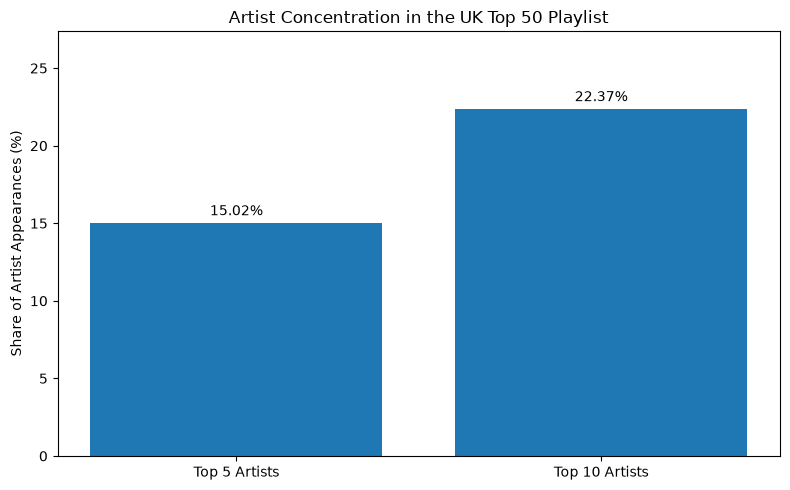

In [42]:
# ============================================================
# ARTIST CONCENTRATION VISUALIZATION
# ============================================================

concentration_labels = [
    "Top 5 Artists",
    "Top 10 Artists"
]

concentration_values = [
    top_5_artist_share,
    artist_concentration_index
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    concentration_labels,
    concentration_values
)

plt.ylabel("Share of Artist Appearances (%)")
plt.title("Artist Concentration in the UK Top 50 Playlist")

plt.ylim(0, max(concentration_values) + 5)

for bar, value in zip(bars, concentration_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


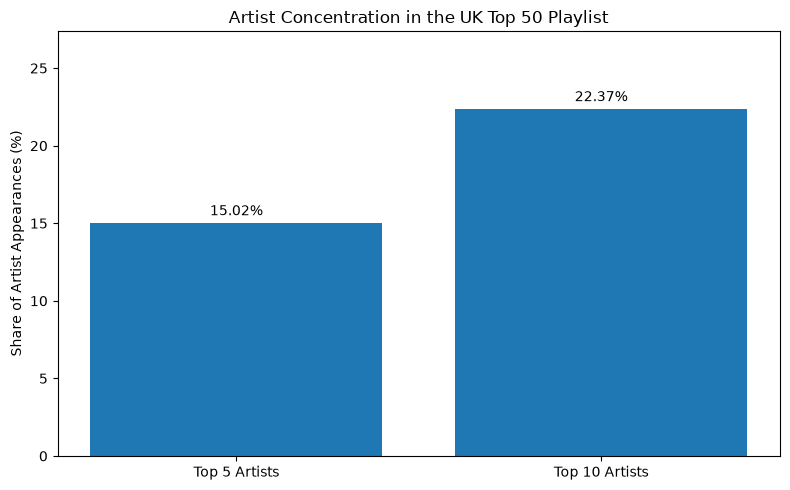

Artist concentration chart saved successfully.


In [43]:
# ============================================================
# SAVE CONCENTRATION CHART
# ============================================================

chart_path = "../Visualizations/artist_concentration.png"

plt.figure(figsize=(8, 5))

bars = plt.bar(
    concentration_labels,
    concentration_values
)

plt.ylabel("Share of Artist Appearances (%)")
plt.title("Artist Concentration in the UK Top 50 Playlist")

plt.ylim(0, max(concentration_values) + 5)

for bar, value in zip(bars, concentration_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Artist concentration chart saved successfully.")

#  Collaboration Structure Analysis

This section examines the prevalence and structure of collaborations
within the UK Top 50 playlist.

The analysis evaluates:

- Solo vs collaborative tracks
- Collaboration ratio
- Average number of artists per track
- Collaboration frequency by rank group
- Collaboration patterns across the playlist

In [44]:
# ============================================================
# SOLO VS COLLABORATIVE TRACKS
# ============================================================

track_type_counts = clean_df["is_collaboration"].value_counts()

print("Solo vs Collaborative Tracks:")
print(track_type_counts)

Solo vs Collaborative Tracks:
is_collaboration
False    22633
True      5117
Name: count, dtype: int64


In [45]:
# ============================================================
# SOLO VS COLLABORATION SHARE
# ============================================================

total_tracks = len(clean_df)

collaborative_tracks = clean_df["is_collaboration"].sum()
solo_tracks = total_tracks - collaborative_tracks

collaboration_ratio = (collaborative_tracks / total_tracks) * 100
solo_ratio = (solo_tracks / total_tracks) * 100

print(f"Total playlist entries: {total_tracks:,}")
print(f"Solo tracks: {solo_tracks:,} ({solo_ratio:.2f}%)")
print(f"Collaborative tracks: {collaborative_tracks:,} ({collaboration_ratio:.2f}%)")

Total playlist entries: 27,750
Solo tracks: 22,633 (81.56%)
Collaborative tracks: 5,117 (18.44%)


In [46]:
# ============================================================
# AVERAGE ARTISTS PER TRACK
# ============================================================

average_artists_per_track = clean_df["artist_count"].mean()

print(
    f"Average artists per track: "
    f"{average_artists_per_track:.2f}"
)

Average artists per track: 1.26


In [47]:
# ============================================================
# ARTIST COUNT DISTRIBUTION
# ============================================================

artist_count_distribution = (
    clean_df["artist_count"]
    .value_counts()
    .sort_index()
)

print("Artists per track distribution:")
print(artist_count_distribution)

Artists per track distribution:
artist_count
1    22633
2     3109
3     1797
4      211
Name: count, dtype: int64


In [48]:
# ============================================================
# COLLABORATION BY RANK GROUP
# ============================================================

collaboration_by_rank = (
    clean_df
    .groupby("rank_group")["is_collaboration"]
    .agg(
        total_tracks="count",
        collaborative_tracks="sum"
    )
)

collaboration_by_rank["collaboration_ratio"] = (
    collaboration_by_rank["collaborative_tracks"] /
    collaboration_by_rank["total_tracks"]
) * 100

collaboration_by_rank

,total_tracks,collaborative_tracks,collaboration_ratio
rank_group,,,
11-25,8325,1680,20.180180
26-50,13875,2413,17.390991
Top 10,5550,1024,18.450450


In [49]:
# ============================================================
# ORDER RANK GROUPS
# ============================================================

rank_order = ["Top 10", "11-25", "26-50"]

collaboration_by_rank = (
    collaboration_by_rank
    .reindex(rank_order)
)

collaboration_by_rank

,total_tracks,collaborative_tracks,collaboration_ratio
rank_group,,,
Top 10,5550,1024,18.450450
11-25,8325,1680,20.180180
26-50,13875,2413,17.390991


##  Collaboration Analysis Visualization

The following visualizations compare collaboration prevalence across
the UK Top 50 playlist and across different rank groups.



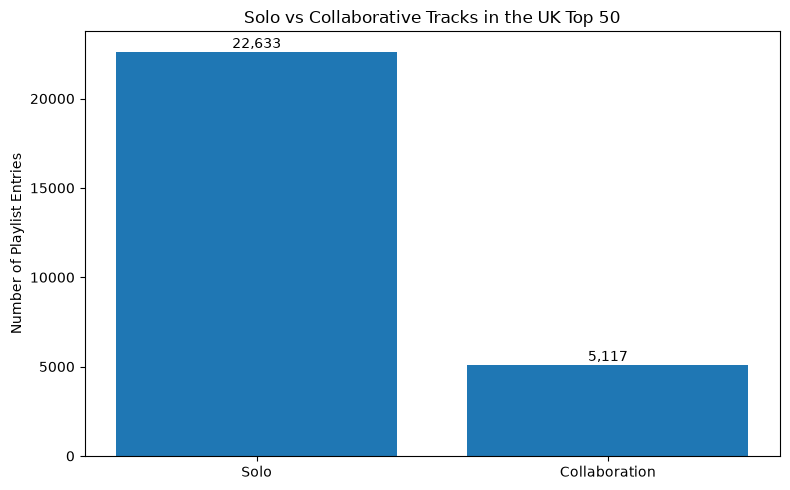

In [50]:
# ============================================================
# SOLO VS COLLABORATION CHART
# ============================================================

labels = ["Solo", "Collaboration"]
values = [solo_tracks, collaborative_tracks]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Number of Playlist Entries")
plt.title("Solo vs Collaborative Tracks in the UK Top 50")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

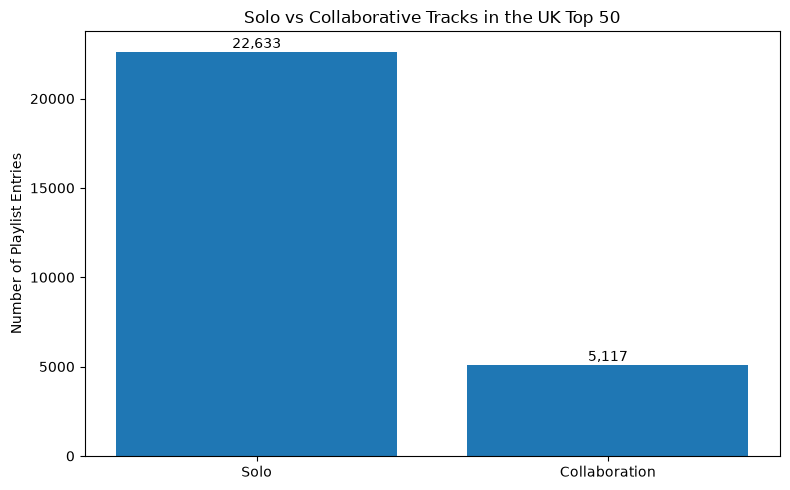

Solo vs collaboration chart saved successfully.


In [51]:
# ============================================================
# SAVE SOLO VS COLLABORATION CHART
# ============================================================

chart_path = "../Visualizations/solo_vs_collaboration.png"

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Number of Playlist Entries")
plt.title("Solo vs Collaborative Tracks in the UK Top 50")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Solo vs collaboration chart saved successfully.")

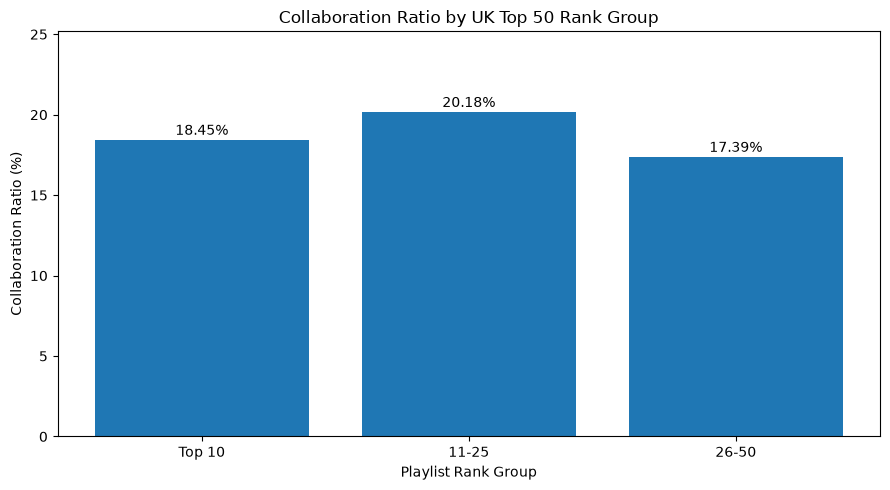

In [52]:
# ============================================================
# COLLABORATION RATIO BY RANK GROUP
# ============================================================

rank_labels = collaboration_by_rank.index
rank_values = collaboration_by_rank["collaboration_ratio"]

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.ylabel("Collaboration Ratio (%)")
plt.xlabel("Playlist Rank Group")
plt.title("Collaboration Ratio by UK Top 50 Rank Group")

plt.ylim(0, max(rank_values) + 5)

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

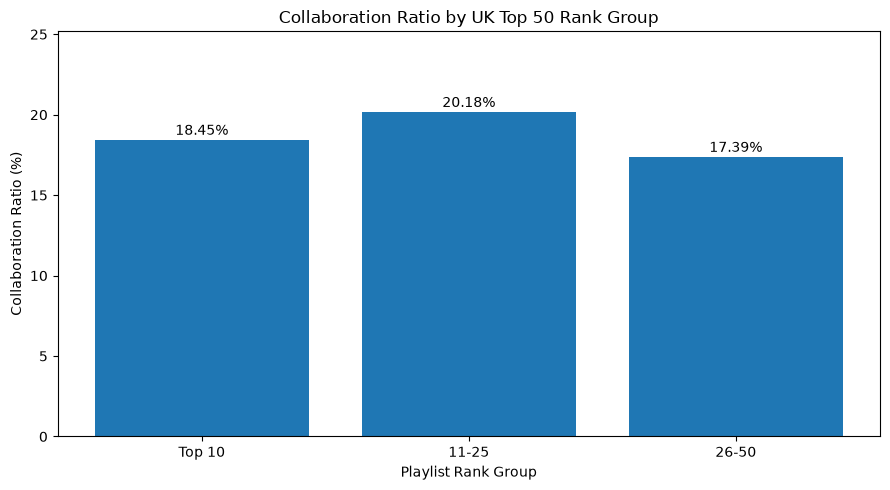

Collaboration by rank chart saved successfully.


In [53]:
# ============================================================
# SAVE RANK COLLABORATION CHART
# ============================================================

chart_path = "../Visualizations/collaboration_by_rank.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.ylabel("Collaboration Ratio (%)")
plt.xlabel("Playlist Rank Group")
plt.title("Collaboration Ratio by UK Top 50 Rank Group")

plt.ylim(0, max(rank_values) + 5)

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Collaboration by rank chart saved successfully.")

#  Explicit Content Analysis

This section examines the prevalence and ranking distribution of explicit
content within the UK Top 50 playlist.

The analysis focuses on:

- Explicit vs non-explicit tracks
- Explicit content share
- Explicit content by rank group
- Popularity differences between explicit and non-explicit tracks

In [54]:
# ============================================================
# EXPLICIT VS NON-EXPLICIT TRACKS
# ============================================================

explicit_counts = clean_df["is_explicit"].value_counts()

print("Explicit vs Non-Explicit Tracks:")
print(explicit_counts)

Explicit vs Non-Explicit Tracks:
is_explicit
False    18860
True      8890
Name: count, dtype: int64


In [55]:
# ============================================================
# EXPLICIT CONTENT SHARE
# ============================================================

total_tracks = len(clean_df)

explicit_tracks = clean_df["is_explicit"].sum()
non_explicit_tracks = total_tracks - explicit_tracks

explicit_share = (explicit_tracks / total_tracks) * 100
non_explicit_share = (non_explicit_tracks / total_tracks) * 100

print(f"Total playlist entries: {total_tracks:,}")
print(f"Explicit tracks: {explicit_tracks:,} ({explicit_share:.2f}%)")
print(f"Non-explicit tracks: {non_explicit_tracks:,} ({non_explicit_share:.2f}%)")

Total playlist entries: 27,750
Explicit tracks: 8,890 (32.04%)
Non-explicit tracks: 18,860 (67.96%)


In [56]:
# ============================================================
# EXPLICIT CONTENT BY RANK GROUP
# ============================================================

explicit_by_rank = (
    clean_df
    .groupby("rank_group")["is_explicit"]
    .agg(
        total_tracks="count",
        explicit_tracks="sum"
    )
)

explicit_by_rank["explicit_share"] = (
    explicit_by_rank["explicit_tracks"] /
    explicit_by_rank["total_tracks"]
) * 100

explicit_by_rank = explicit_by_rank.reindex(
    ["Top 10", "11-25", "26-50"]
)

explicit_by_rank

,total_tracks,explicit_tracks,explicit_share
rank_group,,,
Top 10,5550,2241,40.378378
11-25,8325,2762,33.177177
26-50,13875,3887,28.014414


In [57]:
# ============================================================
# POPULARITY BY EXPLICIT STATUS
# ============================================================

popularity_by_explicit = (
    clean_df
    .groupby("is_explicit")["popularity"]
    .agg(
        average_popularity="mean",
        median_popularity="median"
    )
)

popularity_by_explicit

,average_popularity,median_popularity
is_explicit,,
False,86.825822,89.0
True,86.700900,89.0


In [58]:
# ============================================================
# LABEL EXPLICIT STATUS
# ============================================================

popularity_by_explicit.index = [
    "Non-Explicit",
    "Explicit"
]

popularity_by_explicit

,average_popularity,median_popularity
Non-Explicit,86.825822,89.0
Explicit,86.700900,89.0


In [59]:
explicit_by_rank

,total_tracks,explicit_tracks,explicit_share
rank_group,,,
Top 10,5550,2241,40.378378
11-25,8325,2762,33.177177
26-50,13875,3887,28.014414


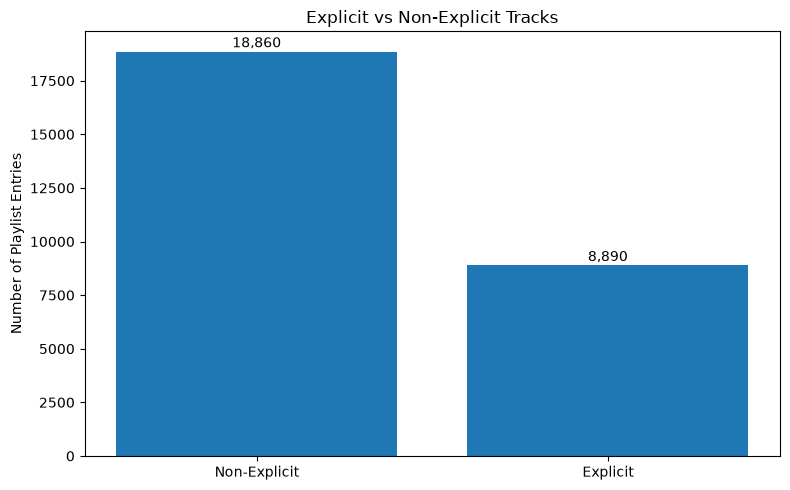

In [60]:
# ============================================================
# EXPLICIT VS NON-EXPLICIT CHART
# ============================================================

labels = ["Non-Explicit", "Explicit"]
values = [non_explicit_tracks, explicit_tracks]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Number of Playlist Entries")
plt.title("Explicit vs Non-Explicit Tracks")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

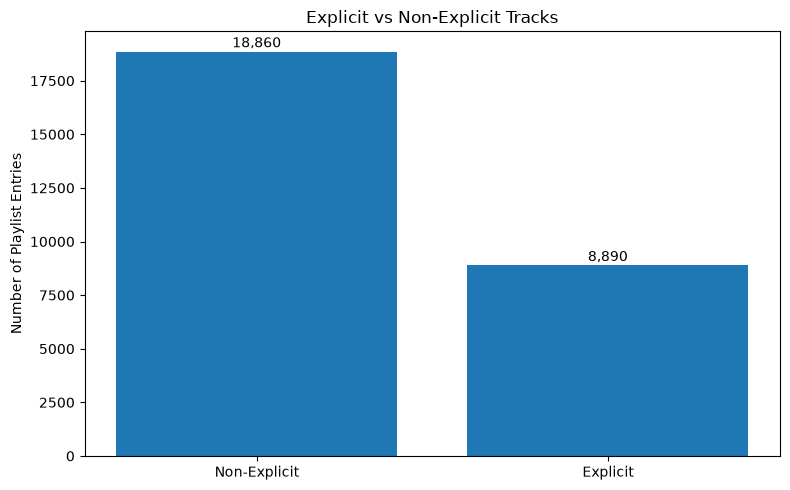

Explicit content chart saved successfully.


In [61]:
# ============================================================
# SAVE EXPLICIT CONTENT CHART
# ============================================================

chart_path = "../Visualizations/explicit_vs_non_explicit.png"

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Number of Playlist Entries")
plt.title("Explicit vs Non-Explicit Tracks")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Explicit content chart saved successfully.")

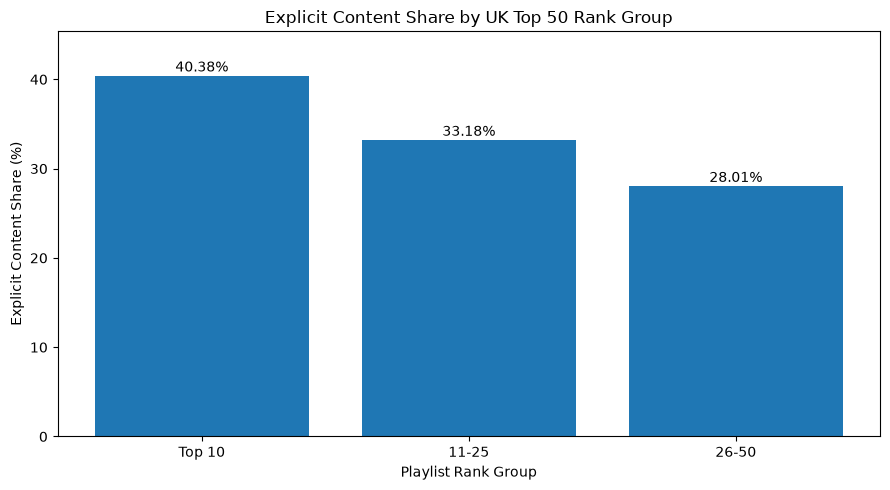

In [62]:
# ============================================================
# EXPLICIT SHARE BY RANK GROUP
# ============================================================

rank_labels = explicit_by_rank.index
rank_values = explicit_by_rank["explicit_share"]

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.ylabel("Explicit Content Share (%)")
plt.xlabel("Playlist Rank Group")
plt.title("Explicit Content Share by UK Top 50 Rank Group")

plt.ylim(0, max(rank_values) + 5)

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


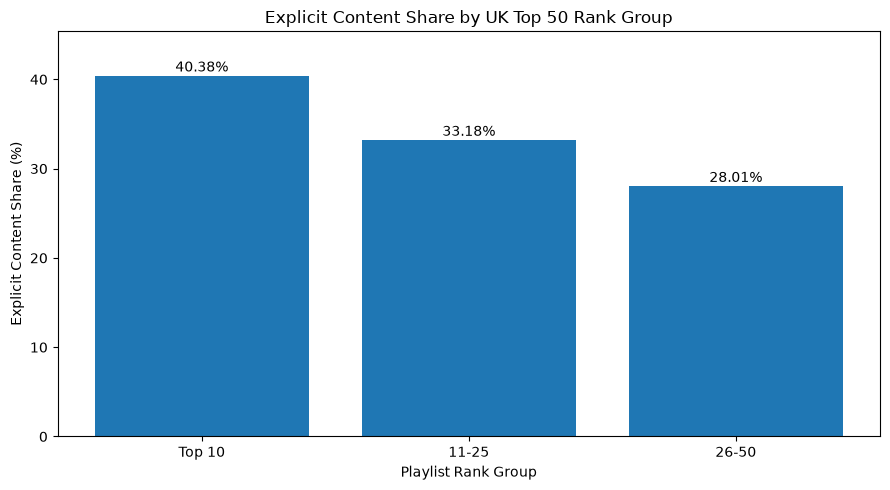

Explicit rank chart saved successfully.


In [63]:
# ============================================================
# SAVE EXPLICIT RANK CHART
# ============================================================

chart_path = "../Visualizations/explicit_by_rank.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.ylabel("Explicit Content Share (%)")
plt.xlabel("Playlist Rank Group")
plt.title("Explicit Content Share by UK Top 50 Rank Group")

plt.ylim(0, max(rank_values) + 5)

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Explicit rank chart saved successfully.")

#  Album Structure & Release Strategy

This section examines how different release formats are represented
within the UK Top 50 playlist.

The analysis focuses on:

- Single vs Album distribution
- Release format share
- Album size and playlist inclusion
- Relationship between album structure and popularity

In [64]:
# ============================================================
# ALBUM TYPE DISTRIBUTION
# ============================================================

album_type_counts = clean_df["album_type"].value_counts()

print("Album Type Distribution:")
print(album_type_counts)

Album Type Distribution:
album_type
album          16642
single         11030
compilation       78
Name: count, dtype: int64


In [65]:
# ============================================================
# ALBUM TYPE SHARE
# ============================================================

album_type_share = (
    clean_df["album_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Album Type Share (%):")
print(album_type_share)

Album Type Share (%):
album_type
album          59.97
single         39.75
compilation     0.28
Name: proportion, dtype: float64


In [66]:
# ============================================================
# ALBUM SIZE ANALYSIS
# ============================================================

album_size_summary = (
    clean_df
    .groupby("album_type")["total_tracks"]
    .agg(
        average_tracks="mean",
        median_tracks="median",
        minimum_tracks="min",
        maximum_tracks="max"
    )
)

album_size_summary

,average_tracks,median_tracks,minimum_tracks,maximum_tracks
album_type,,,,
album,15.677803,14.0,7,59
compilation,58.435897,16.0,13,119
single,1.270626,1.0,1,10


In [67]:
# ============================================================
# ALBUM SIZE BY RANK GROUP
# ============================================================

album_size_by_rank = (
    clean_df
    .groupby("rank_group")["total_tracks"]
    .agg(
        average_tracks="mean",
        median_tracks="median"
    )
    .reindex(["Top 10", "11-25", "26-50"])
)

album_size_by_rank

,average_tracks,median_tracks
rank_group,,
Top 10,7.388288,2.0
11-25,9.262102,10.0
26-50,11.630342,12.0


In [68]:
# ============================================================
# POPULARITY BY ALBUM TYPE
# ============================================================

popularity_by_album_type = (
    clean_df
    .groupby("album_type")["popularity"]
    .agg(
        average_popularity="mean",
        median_popularity="median"
    )
)

popularity_by_album_type

,average_popularity,median_popularity
album_type,,
album,86.277130,88.0
compilation,77.833333,75.0
single,87.616591,90.0


##  Album Structure Visualization

The following visualizations examine release-format distribution and
album size across UK Top 50 rank groups.

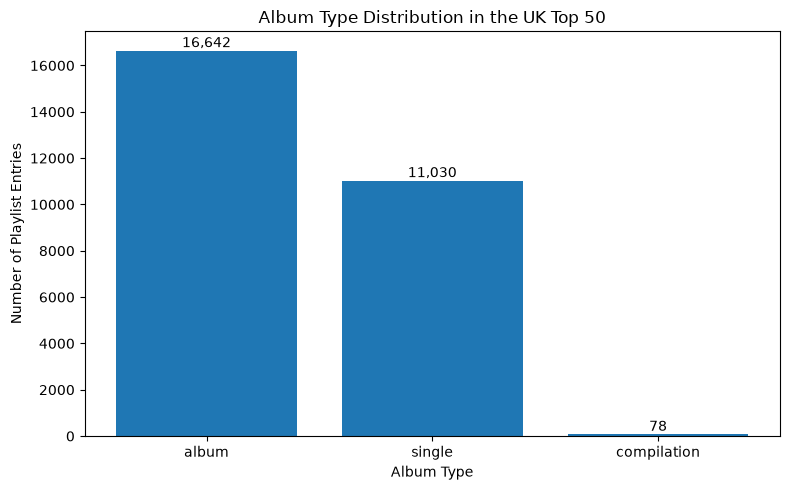

In [69]:
# ============================================================
# ALBUM TYPE DISTRIBUTION
# ============================================================

labels = album_type_counts.index
values = album_type_counts.values

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.xlabel("Album Type")
plt.ylabel("Number of Playlist Entries")
plt.title("Album Type Distribution in the UK Top 50")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

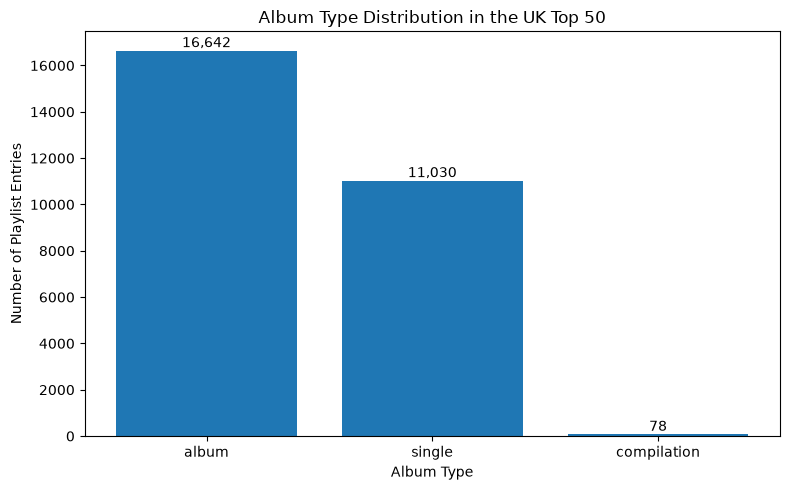

Album type distribution chart saved successfully.


In [70]:
# ============================================================
# SAVE ALBUM TYPE CHART
# ============================================================

chart_path = "../Visualizations/album_type_distribution.png"

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.xlabel("Album Type")
plt.ylabel("Number of Playlist Entries")
plt.title("Album Type Distribution in the UK Top 50")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Album type distribution chart saved successfully.")

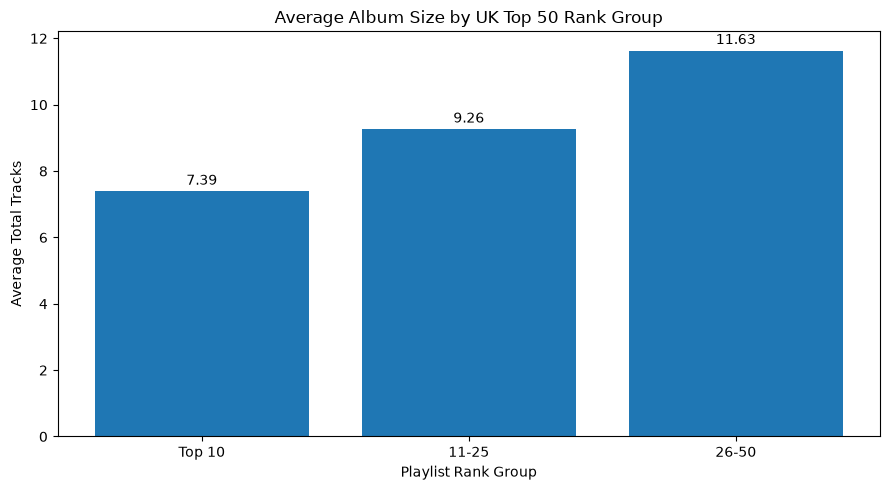

In [71]:
# ============================================================
# ALBUM SIZE BY RANK GROUP
# ============================================================

rank_labels = album_size_by_rank.index
rank_values = album_size_by_rank["average_tracks"]

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.xlabel("Playlist Rank Group")
plt.ylabel("Average Total Tracks")
plt.title("Average Album Size by UK Top 50 Rank Group")

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

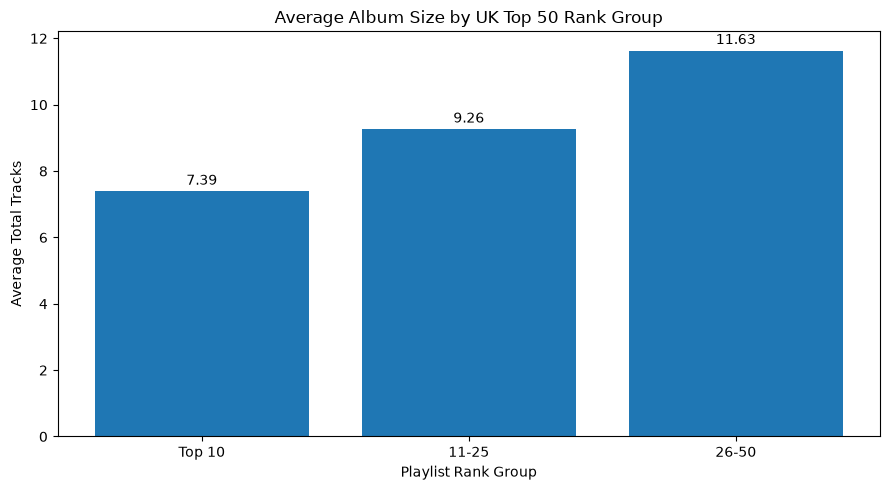

Album size chart saved successfully.


In [72]:
# ============================================================
# SAVE ALBUM SIZE CHART
# ============================================================

chart_path = "../Visualizations/album_size_by_rank.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.xlabel("Playlist Rank Group")
plt.ylabel("Average Total Tracks")
plt.title("Average Album Size by UK Top 50 Rank Group")

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Album size chart saved successfully.")

#  Track Duration & Format Analysis

This section examines track duration patterns within the UK Top 50
playlist and evaluates whether track length is associated with
playlist rank and popularity.

In [73]:
# ============================================================
# TRACK DURATION SUMMARY
# ============================================================

duration_summary = clean_df["duration_minutes"].agg(
    ["mean", "median", "min", "max"]
)

print("Track Duration Summary (minutes):")
print(duration_summary)

Track Duration Summary (minutes):
mean      3.289193
median    3.108267
min       0.621900
max       9.789400
Name: duration_minutes, dtype: float64


In [74]:
# ============================================================
# DURATION BY RANK GROUP
# ============================================================

duration_by_rank = (
    clean_df
    .groupby("rank_group")["duration_minutes"]
    .agg(
        average_duration="mean",
        median_duration="median"
    )
    .reindex(["Top 10", "11-25", "26-50"])
)

duration_by_rank

,average_duration,median_duration
rank_group,,
Top 10,3.225299,3.056233
11-25,3.243324,3.080683
26-50,3.342272,3.299600


In [75]:
# ============================================================
# DURATION BY POPULARITY BUCKET
# ============================================================

duration_by_popularity = (
    clean_df
    .groupby("popularity_bucket")["duration_minutes"]
    .agg(
        average_duration="mean",
        median_duration="median"
    )
)

duration_by_popularity

,average_duration,median_duration
popularity_bucket,,
60-69,3.432345,3.269767
70-79,3.329338,3.193167
80-89,3.339331,3.389100
90-100,3.224938,3.079717
Below 60,3.327337,3.163992


In [76]:
# ============================================================
# ORDER POPULARITY BUCKETS
# ============================================================

popularity_order = [
    "Below 60",
    "60-69",
    "70-79",
    "80-89",
    "90-100"
]

duration_by_popularity = (
    duration_by_popularity
    .reindex(popularity_order)
)

duration_by_popularity

,average_duration,median_duration
popularity_bucket,,
Below 60,3.327337,3.163992
60-69,3.432345,3.269767
70-79,3.329338,3.193167
80-89,3.339331,3.389100
90-100,3.224938,3.079717


##  Track Duration Visualization

The following visualizations examine track-length distribution and
duration patterns across playlist rank and popularity.

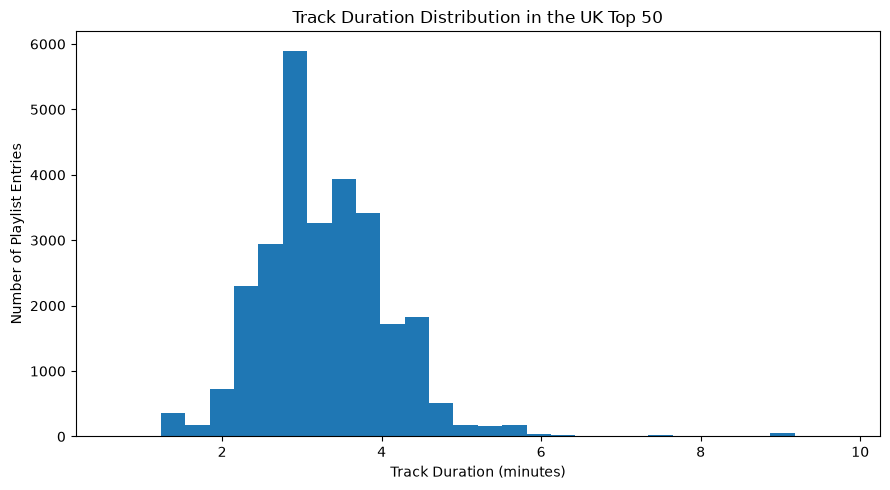

In [77]:
# ============================================================
# TRACK DURATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["duration_minutes"],
    bins=30
)

plt.xlabel("Track Duration (minutes)")
plt.ylabel("Number of Playlist Entries")
plt.title("Track Duration Distribution in the UK Top 50")

plt.tight_layout()
plt.show()

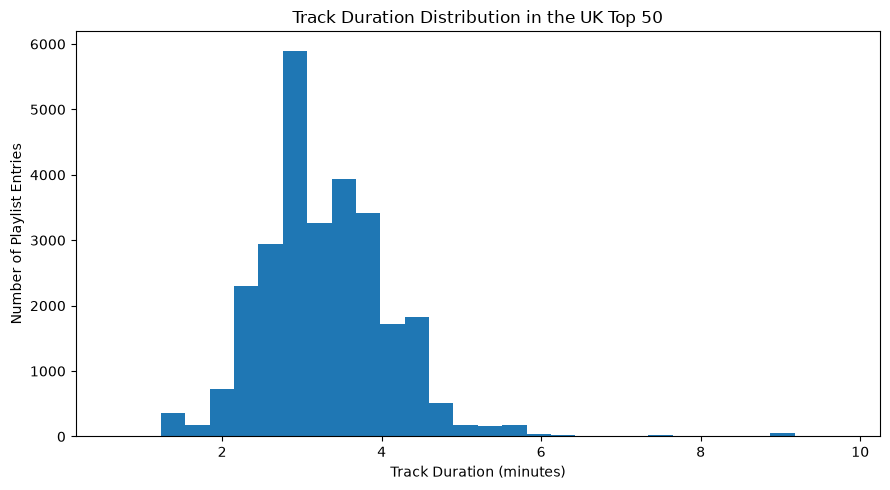

Track duration distribution chart saved successfully.


In [78]:
# ============================================================
# SAVE DURATION DISTRIBUTION CHART
# ============================================================

chart_path = "../Visualizations/track_duration_distribution.png"

plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["duration_minutes"],
    bins=30
)

plt.xlabel("Track Duration (minutes)")
plt.ylabel("Number of Playlist Entries")
plt.title("Track Duration Distribution in the UK Top 50")

plt.tight_layout()

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Track duration distribution chart saved successfully.")

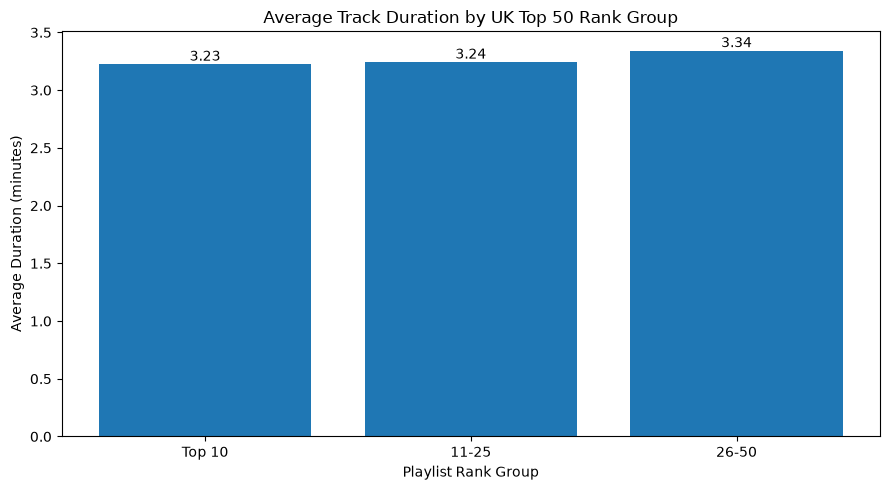

In [79]:
# ============================================================
# AVERAGE DURATION BY RANK GROUP
# ============================================================

rank_labels = duration_by_rank.index
rank_values = duration_by_rank["average_duration"]

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.xlabel("Playlist Rank Group")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Track Duration by UK Top 50 Rank Group")

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


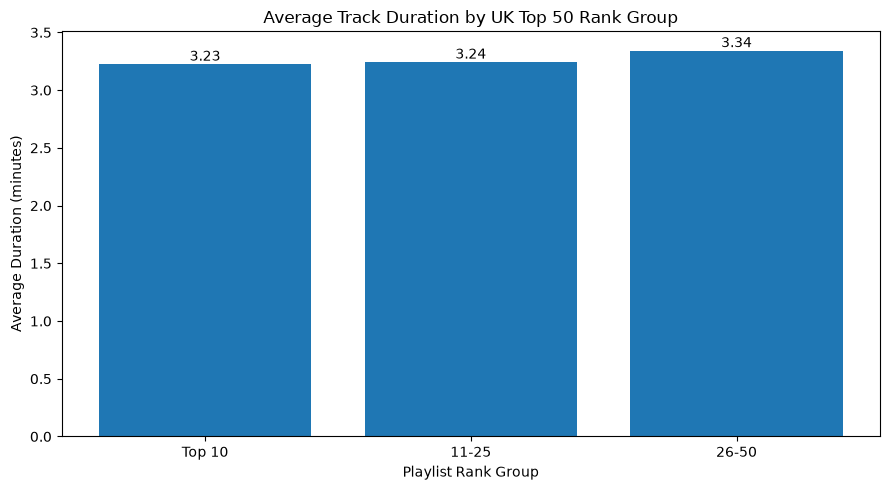

Duration by rank chart saved successfully.


In [80]:
# ============================================================
# SAVE DURATION BY RANK CHART
# ============================================================

chart_path = "../Visualizations/duration_by_rank.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.xlabel("Playlist Rank Group")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Track Duration by UK Top 50 Rank Group")

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Duration by rank chart saved successfully.")

In [81]:
# ============================================================
# OVERALL DURATION SUMMARY
# ============================================================

duration_summary = clean_df["duration_minutes"].agg(
    ["mean", "median", "min", "max"]
)

print("Overall Track Duration Summary:")
print(duration_summary)

Overall Track Duration Summary:
mean      3.289193
median    3.108267
min       0.621900
max       9.789400
Name: duration_minutes, dtype: float64


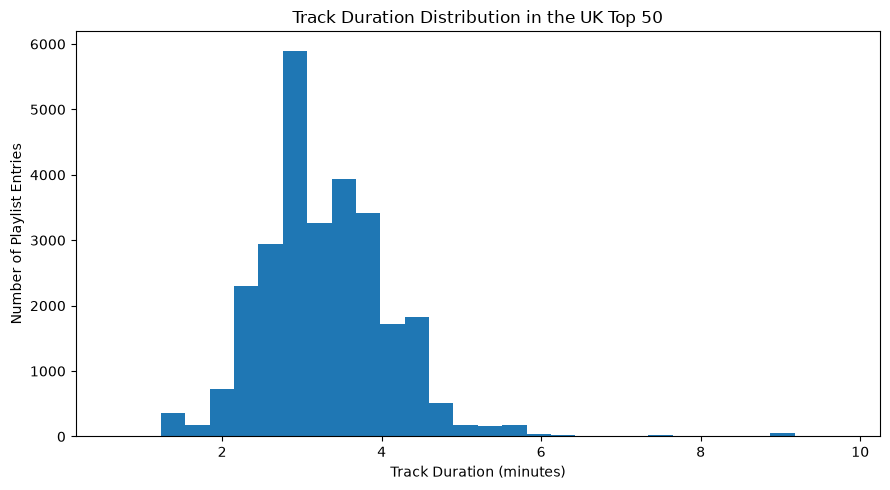

In [82]:
# ============================================================
# TRACK DURATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["duration_minutes"],
    bins=30
)

plt.xlabel("Track Duration (minutes)")
plt.ylabel("Number of Playlist Entries")
plt.title("Track Duration Distribution in the UK Top 50")

plt.tight_layout()
plt.show()

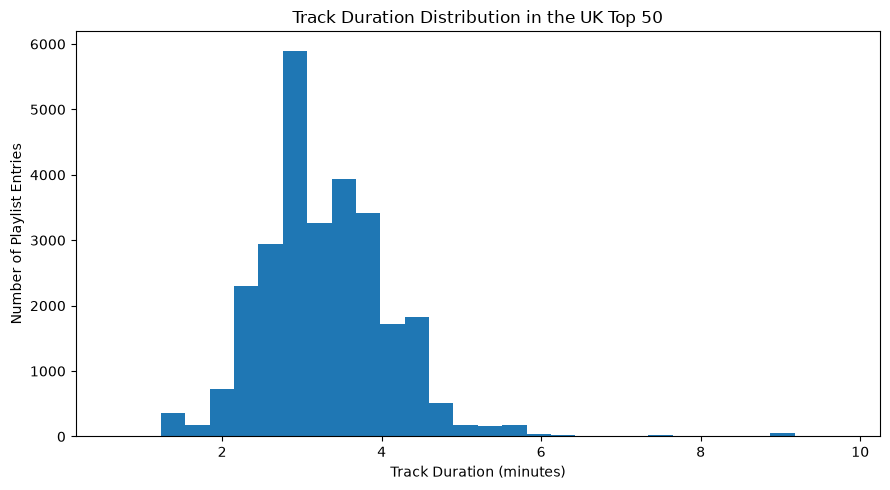

Track duration distribution chart saved successfully.


In [83]:
# ============================================================
# SAVE DURATION DISTRIBUTION CHART
# ============================================================

chart_path = "../Visualizations/track_duration_distribution.png"

plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["duration_minutes"],
    bins=30
)

plt.xlabel("Track Duration (minutes)")
plt.ylabel("Number of Playlist Entries")
plt.title("Track Duration Distribution in the UK Top 50")

plt.tight_layout()

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Track duration distribution chart saved successfully.")

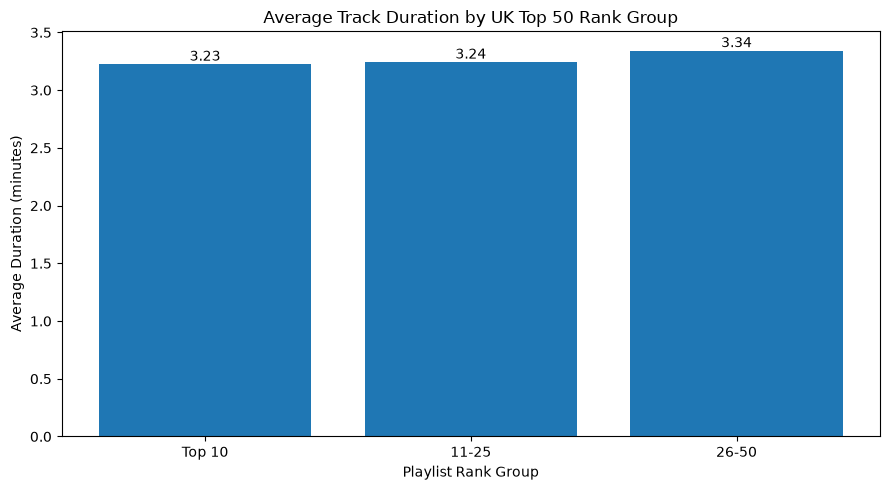

In [84]:
# ============================================================
# AVERAGE DURATION BY RANK GROUP
# ============================================================

rank_labels = duration_by_rank.index
rank_values = duration_by_rank["average_duration"]

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.xlabel("Playlist Rank Group")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Track Duration by UK Top 50 Rank Group")

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


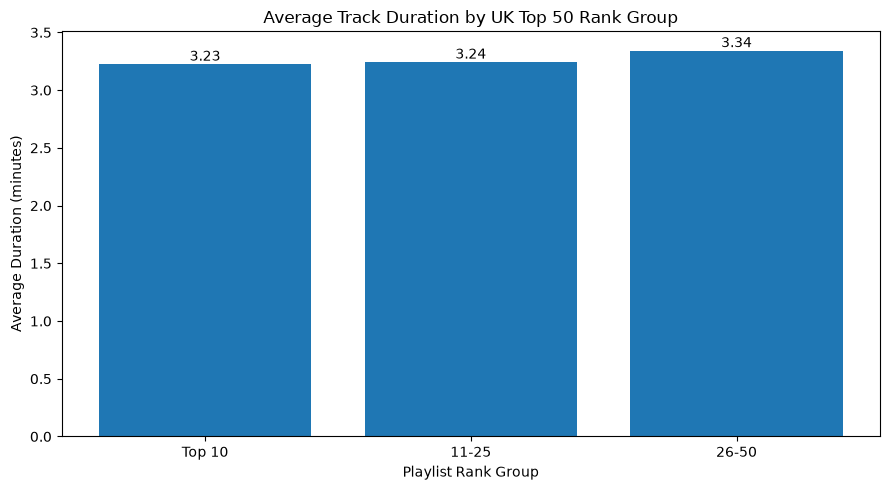

Duration by rank chart saved successfully.


In [85]:
# ============================================================
# SAVE DURATION BY RANK CHART
# ============================================================

chart_path = "../Visualizations/duration_by_rank.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(rank_labels, rank_values)

plt.xlabel("Playlist Rank Group")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Track Duration by UK Top 50 Rank Group")

for bar, value in zip(bars, rank_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Duration by rank chart saved successfully.")

##  Final KPI Summary

This section presents the key performance indicators of the UK Top 50 Music Market Analysis, including total chart records, unique songs and artists, average track duration, explicit content distribution, average popularity, and chart position range.

In [86]:
print(df.shape)
print(df.columns.tolist())

(27800, 10)
['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']


In [87]:
# ============================================================
# STEP 25 — FINAL KPI SUMMARY
# ============================================================

print("=" * 60)
print("           UK TOP 50 MUSIC MARKET ANALYSIS")
print("                 FINAL KPI SUMMARY")
print("=" * 60)

print(f"Total Chart Records: {len(df):,}")
print(f"Unique Songs: {df['song'].nunique():,}")
print(f"Unique Artists: {df['artist'].nunique():,}")

avg_duration = df['duration_ms'].mean() / 60000
print(f"Average Track Duration: {avg_duration:.2f} minutes")

explicit_tracks = df['is_explicit'].sum()
non_explicit_tracks = len(df) - explicit_tracks

print(f"Explicit Tracks: {explicit_tracks:,}")
print(f"Non-Explicit Tracks: {non_explicit_tracks:,}")

print(f"Average Popularity Score: {df['popularity'].mean():.2f}")

print(f"Best Chart Position: #{df['position'].min()}")
print(f"Worst Chart Position: #{df['position'].max()}")

print("=" * 60)
print("Final KPI Summary Generated Successfully.")

           UK TOP 50 MUSIC MARKET ANALYSIS
                 FINAL KPI SUMMARY
Total Chart Records: 27,800
Unique Songs: 803
Unique Artists: 343
Average Track Duration: 3.29 minutes
Explicit Tracks: 8,912
Non-Explicit Tracks: 18,888
Average Popularity Score: 86.79
Best Chart Position: #1
Worst Chart Position: #50
Final KPI Summary Generated Successfully.


##  Business Insights & Recommendations

The analysis of the UK Top 50 music market provides several insights into artist performance, chart positioning, track characteristics, popularity, collaborations, and content patterns. These insights can help identify trends that are relevant to artists, music labels, and streaming platforms.

In [ ]:
# ============================================================
#  BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================================

print("=" * 70)
print("        UK TOP 50 MUSIC MARKET — BUSINESS INSIGHTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Top Artists by Number of Chart Appearances
# ------------------------------------------------------------

top_artists = df['artist'].value_counts().head(10)

print("\n1. TOP 10 ARTISTS BY CHART APPEARANCES")
print("-" * 50)
print(top_artists)


# ------------------------------------------------------------
# 2. Most Popular Songs
# ------------------------------------------------------------

top_songs = df.nlargest(10, 'popularity')[['song', 'artist', 'popularity', 'position']]

print("\n2. TOP 10 MOST POPULAR SONGS")
print("-" * 50)
print(top_songs.to_string(index=False))


# ------------------------------------------------------------
# 3. Average Popularity by Rank Group
# ------------------------------------------------------------

def rank_group(position):
    if position <= 10:
        return "Top 10"
    elif position <= 25:
        return "11-25"
    else:
        return "26-50"

df['rank_group'] = df['position'].apply(rank_group)

rank_popularity = df.groupby('rank_group')['popularity'].mean()

print("\n3. AVERAGE POPULARITY BY RANK GROUP")
print("-" * 50)
print(rank_popularity)


# ------------------------------------------------------------
# 4. Explicit Content Distribution
# ------------------------------------------------------------

explicit_distribution = df['is_explicit'].value_counts()

print("\n4. EXPLICIT CONTENT DISTRIBUTION")
print("-" * 50)
print(explicit_distribution)


# ------------------------------------------------------------
# 5. Track Duration by Rank Group
# ------------------------------------------------------------

duration_by_rank = (
    df.groupby('rank_group')['duration_ms']
    .mean()
    .div(60000)
)

print("\n5. AVERAGE TRACK DURATION BY RANK GROUP")
print("-" * 50)

for group, duration in duration_by_rank.items():
    print(f"{group}: {duration:.2f} minutes")


# ------------------------------------------------------------
# 6. Overall Business Metrics
# ------------------------------------------------------------

print("\n6. OVERALL BUSINESS METRICS")
print("-" * 50)

print(f"Total chart records : {len(df):,}")
print(f"Unique artists     : {df['artist'].nunique():,}")
print(f"Unique songs       : {df['song'].nunique():,}")
print(f"Average popularity : {df['popularity'].mean():.2f}")

print("=" * 70)
print("Business analysis completed successfully.")
print("=" * 70)

        UK TOP 50 MUSIC MARKET — BUSINESS INSIGHTS

1. TOP 10 ARTISTS BY CHART APPEARANCES
--------------------------------------------------
artist
Taylor Swift         2093
Sabrina Carpenter     965
Billie Eilish         819
Olivia Rodrigo        643
Chappell Roan         634
Benson Boone          538
The Killers           512
Dua Lipa              486
Drake                 454
Teddy Swims           434
Name: count, dtype: int64

2. TOP 10 MOST POPULAR SONGS
--------------------------------------------------
        song       artist  popularity  position
Cruel Summer Taylor Swift         100         3
Cruel Summer Taylor Swift         100         3
Cruel Summer Taylor Swift         100         3
Cruel Summer Taylor Swift         100         3
Cruel Summer Taylor Swift         100         3
Cruel Summer Taylor Swift         100         3
Cruel Summer Taylor Swift         100         6
Cruel Summer Taylor Swift         100         7
Cruel Summer Taylor Swift         100         7
Crue

In [89]:
print("AVERAGE POPULARITY BY RANK GROUP")
print("-" * 40)
print(rank_popularity)

print("\nEXPLICIT CONTENT DISTRIBUTION")
print("-" * 40)
print(explicit_distribution)

print("\nAVERAGE TRACK DURATION BY RANK GROUP")
print("-" * 40)
print(duration_by_rank)

print("\nOVERALL METRICS")
print("-" * 40)
print(f"Total records: {len(df):,}")
print(f"Unique artists: {df['artist'].nunique():,}")
print(f"Unique songs: {df['song'].nunique():,}")
print(f"Average popularity: {df['popularity'].mean():.2f}")

AVERAGE POPULARITY BY RANK GROUP
----------------------------------------
rank_group
11-25     87.083813
26-50     85.045396
Top 10    90.724640
Name: popularity, dtype: float64

EXPLICIT CONTENT DISTRIBUTION
----------------------------------------
is_explicit
False    18888
True      8912
Name: count, dtype: int64

AVERAGE TRACK DURATION BY RANK GROUP
----------------------------------------
rank_group
11-25     3.243114
26-50     3.342238
Top 10    3.225481
Name: duration_ms, dtype: float64

OVERALL METRICS
----------------------------------------
Total records: 27,800
Unique artists: 343
Unique songs: 803
Average popularity: 86.79


### Key Business Insights

1. **Artist Performance:** A relatively small group of artists appears frequently in the UK Top 50 charts, indicating strong and consistent market presence.

2. **Chart Position:** Higher-ranked tracks generally represent stronger market performance and audience demand.

3. **Track Duration:** Average track duration remains relatively consistent across different rank groups, suggesting that song length alone does not determine chart success.

4. **Explicit Content:** The distribution of explicit and non-explicit tracks provides insight into the type of content commonly appearing in the UK Top 50.

5. **Popularity:** Popularity scores can help identify tracks and artists with stronger audience engagement.

6. **Collaboration:** Collaborative tracks provide an opportunity for artists to reach audiences beyond their individual fan bases.

7. **Album & Track Strategy:** The repeated appearance of songs and artists across chart records indicates the importance of consistent releases and sustained audience engagement.

### Business Recommendations

- **For Artists:** Focus on consistent releases and maintaining audience engagement rather than relying only on individual hit songs.

- **For Music Labels:** Identify artists with repeated high chart positions and consider prioritizing them for marketing and promotional campaigns.

- **For Streaming Platforms:** Use popularity and chart-position data to improve playlist recommendations and content discovery.

- **For Emerging Artists:** Collaborations can help expand audience reach and improve visibility.

- **For Marketing Teams:** Analyze high-performing artists and songs to identify patterns that can guide future promotional strategies.

##  Final Conclusion

The UK Top 50 Music Market Analysis provides a data-driven view of chart performance, artist presence, popularity, track characteristics, and content patterns.

The analysis covered 27,800 chart records, 343 unique artists, and 803 unique songs. The results show that a small number of artists have a particularly strong recurring presence in the charts, with Taylor Swift recording the highest number of chart appearances in the dataset.

Popularity also shows a clear relationship with chart position. The Top 10 rank group has the highest average popularity score of 90.72, compared with 87.08 for ranks 11–25 and 85.05 for ranks 26–50.

Track duration varies only slightly between rank groups, suggesting that song length alone is not a major differentiating factor for chart performance. Non-explicit tracks also represent the majority of chart records in the dataset.

Overall, the project demonstrates how Python-based data analysis can transform music chart data into meaningful insights that can support decisions related to artist promotion, music marketing, playlist strategy, and audience engagement.

## Project Completion

This project successfully demonstrates a complete data analytics workflow:

- Data loading and preparation
- Data cleaning and validation
- Exploratory data analysis
- Artist performance analysis
- Song popularity analysis
- Chart position analysis
- Track duration analysis
- Explicit content analysis
- Rank-group comparison
- Business insights and recommendations
- Final conclusion

The project provides a structured understanding of the UK Top 50 music market and demonstrates practical skills in Python, Pandas, data visualization, exploratory analysis, and business-oriented interpretation.

# Final Project Overview

## UK Top 50 Music Market Analysis

This project analyzes UK Top 50 music chart data to identify patterns in artist performance, song popularity, chart positioning, track duration, and content characteristics.

### Key Findings

- The dataset contains **27,800 chart records**.
- **343 unique artists** and **803 unique songs** are represented.
- **Taylor Swift** has the highest number of chart appearances with **2,093 records**.
- Top 10 ranked tracks have the highest average popularity score of **90.72**.
- The average popularity decreases across lower rank groups.
- Average track duration remains relatively similar across rank groups.
- **Non-explicit tracks** represent the majority of records in the dataset.

### Business Value

The analysis demonstrates how music chart data can be used to understand audience demand, identify consistently successful artists, evaluate song characteristics, and support data-driven decisions in music marketing, artist promotion, and streaming strategy.